# Explorar indicadores de presencia de mineros de subsistencia
- La ANM [publica](https://www.anm.gov.co/seleccion-de-datos-abiertos) la base de datos de mineros de subsistencia en tres categorías:
    - [Barequeros](https://www.datos.gov.co/Minas-y-Energ-a/ANM-RUCOM-Explotador-Minero-Autorizado-Mineros-de-/6xd6-hsen/about_data)
    - [Chatarreroros](https://www.datos.gov.co/Minas-y-Energ-a/ANM-RUCOM-Explotador-Minero-Autorizado-Mineros-de-/6uuj-njfp/about_data)
    - [Otros mineros de subsistencia](https://www.datos.gov.co/Minas-y-Energ-a/ANM-RUCOM-Explotador-Minero-Autorizado-Mineros-de-/i2mm-hwz3/about_data)
- El plan es usar esta información como indicador de minería informal en el municipio
- En este cuaderno uno las tres bases de datos y exploro el número de mineros informales por $km^2$ en el municipios



# Herramientas

## Paquetes

In [85]:
# Manejar datos
import pandas as pd
pd.set_option('display.float_format', lambda x: '{:,.2f}'.format(x)) # Configuración para mostrar separador de miles

# Manejar datos espaciales
import geopandas as gpd
from shapely.validation import make_valid

# Calculo numérico
import numpy as np

# Utilidades
from tqdm import tqdm # revisar avance de ciclos
import warnings # Manejar warnings
import unicodedata # Manejar caracteres especiales de los strings

# Gráficas
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

## Parámetros del cuaderno

In [22]:
str_separar = '*'*20 # String para separar resultados cuando los imprimo

# Cargar datos

In [2]:
# Ruta de los archivos

ruta_barequeros = "C:/Users/jcalf/OneDrive - Universidad de los Andes/PEG/Tesis/I3 - Minería y sectores económicos/Data/5_ANM_datos_abiertos/ANM_RUCOM_Explotador_Minero_Autorizado-Mineros_de_Subsistencia_Barequeros_20260406.xlsx"
ruta_chatarreros = 'C:/Users/jcalf/OneDrive - Universidad de los Andes/PEG/Tesis/I3 - Minería y sectores económicos/Data/5_ANM_datos_abiertos/ANM_RUCOM_Explotador_Minero_Autorizado-Mineros_de_Subsistencia_Chatarreros_20260406.xlsx'
ruta_otros = 'C:/Users/jcalf/OneDrive - Universidad de los Andes/PEG/Tesis/I3 - Minería y sectores económicos/Data/5_ANM_datos_abiertos/ANM_RUCOM_Explotador_Minero_Autorizado-Mineros_de_Subsistencia_Otros_Mineros_De_Subsistencia_20260406.xlsx'

# Cargar datos y asegurarse que el código DANE se lee como string
barequeros = pd.read_excel(ruta_barequeros, dtype={'CODIGO_DANE':str})
chatarreros = pd.read_excel(ruta_chatarreros, dtype={'CODIGO_DANE':str})
otros = pd.read_excel(ruta_otros, dtype={'CODIGO_DANE':str})

In [3]:
# Explorar datos de los mineros de subsistencia
print(f"{'*'*20} Barequeros")
display(barequeros.info())

print(f"\n{'*'*20} Chatarreros")
display(chatarreros.info())

print(f"\n{'*'*20} Otros")
display(otros.info())

******************** Barequeros
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74554 entries, 0 to 74553
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   NOMBRE        74554 non-null  object
 1   MINERAL       74554 non-null  object
 2   MUNICIPIO     74554 non-null  object
 3   DEPARTAMENTO  74554 non-null  object
 4   CODIGO_DANE   74554 non-null  object
dtypes: object(5)
memory usage: 2.8+ MB


None


******************** Chatarreros
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   NOMBRE_PERSONA  545 non-null    object
 1   MINERALES       545 non-null    object
 2   MUNICIPIO       545 non-null    object
 3   DEPARTAMENTO    545 non-null    object
 4   CODIGO_DANE     545 non-null    object
dtypes: object(5)
memory usage: 21.4+ KB


None


******************** Otros
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6022 entries, 0 to 6021
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   NOMBRE_PERSONA  6022 non-null   object
 1   MINERALES       6022 non-null   object
 2   MUNICIPIO       6022 non-null   object
 3   DEPARTAMENTO    6022 non-null   object
 4   CODIGO_DANE     6022 non-null   object
dtypes: object(5)
memory usage: 235.4+ KB


None

# Unir bases de datos

In [4]:
# Crear identificador del tipo de minería de subsistencia
barequeros['Minero_subsistencia'] = 'Barequeros'
chatarreros['Minero_subsistencia'] = 'Chatarrero'
otros['Minero_subsistencia'] = 'Otros'

# Armonizar nombres de las columna
barequeros = barequeros.rename(columns={'NOMBRE':'NOMBRE_PERSONA',
                                       'MINERAL':'MINERALES'})

In [5]:
# Unir dataframes
mineros_subsistencia = pd.concat([barequeros, chatarreros, otros])

# Explorar conteo de nombres únicos por cada tipo de minería de subsistencia
display(mineros_subsistencia.groupby('Minero_subsistencia')['NOMBRE_PERSONA'].nunique())

Minero_subsistencia
Barequeros    74469
Chatarrero      545
Otros          6020
Name: NOMBRE_PERSONA, dtype: int64

# Explorar valores duplicados

In [6]:
# Revisar valores duplicados
# La misma persona puede aparecer como "Chatarrero" y "Otros" en el mismo municipio
display(mineros_subsistencia[mineros_subsistencia.duplicated(subset='NOMBRE_PERSONA')].sort_values('NOMBRE_PERSONA'))

# También hay casos en que simplemente el registro está repetido
display(mineros_subsistencia[mineros_subsistencia['NOMBRE_PERSONA']=='ZUNILDA MENDOZA RIVAS'])

,NOMBRE_PERSONA,MINERALES,MUNICIPIO,DEPARTAMENTO,CODIGO_DANE,Minero_subsistencia
2991,AARON DAVID CUADROS RUIZ,METALES PRECIOSOS,REMEDIOS,ANTIOQUIA,05604,Otros
2604,ABEL ENRIQUE SUAREZ MONTALVO,METALES PRECIOSOS,CAUCASIA,ANTIOQUIA,05154,Otros
5576,ABEL IGNACIO SALAZAR MENDEZ,METALES PRECIOSOS,SAN JOSE DE URE,CORDOBA,23682,Otros
3853,ABEL TAVERA DIAZ,"ESMERALDAS,GRAVAS DE RIO,ARCILLA,MORRALLA,AREN...",CHIMA,SANTANDER,68176,Otros
349,ABEL TAVERA DIAZ,"ESMERALDAS,ARENAS DE RIO,MORRALLA,ARCILLA,GRAV...",CHIMA,SANTANDER,68176,Chatarrero
...,...,...,...,...,...,...
1028,ZULY PAOLA FLOREZ DE ANDRES,METALES PRECIOSOS,CAUCASIA,ANTIOQUIA,05154,Otros
691,ZUNILDA VELLOJIN FURNIELES,METALES PRECIOSOS,SAN JOSE DE URE,CORDOBA,23682,Otros
74542,ZUNILDA MENDOZA RIVAS,METALES PRECIOSOS,UNIÓN PANAMERICANA ( Animas),CHOCO,27810,Barequeros
36,ZUNY CENTENO CENTENO,"ESMERALDAS,METALES PRECIOSOS,ARENAS DE RIO,MOR...",MAGÜÍ (Payán),NARIÑO,52427,Chatarrero


,NOMBRE_PERSONA,MINERALES,MUNICIPIO,DEPARTAMENTO,CODIGO_DANE,Minero_subsistencia
74541,ZUNILDA MENDOZA RIVAS,METALES PRECIOSOS,UNIÓN PANAMERICANA ( Animas),CHOCO,27810,Barequeros
74542,ZUNILDA MENDOZA RIVAS,METALES PRECIOSOS,UNIÓN PANAMERICANA ( Animas),CHOCO,27810,Barequeros


## Limpiar strings de Minerales

In [7]:
# Exportar strings de la columna "MINERALES" a Excel para análisis manual
pd.DataFrame(mineros_subsistencia['MINERALES'].unique()).head(10)

,0
0,METALES PRECIOSOS
1,"ESMERALDAS,GRAVAS DE RIO,ARCILLA,MORRALLA,AREN..."
2,"METALES PRECIOSOS,METALES PRECIOSOS"
3,"ESMERALDAS,PIEDRAS SEMIPRECIOSAS,PIEDRAS PRECI..."
4,"ESMERALDAS,MORRALLA"
5,"ESMERALDAS,ARCILLA,MORRALLA,ARENAS DE RIO,PIED..."
6,"GRAVAS DE RIO,METALES PRECIOSOS,ARCILLA,ARENAS..."
7,"ESMERALDAS,METALES PRECIOSOS,PIEDRAS PRECIOSAS..."
8,"MORRALLA,ESMERALDAS"
9,"METALES PRECIOSOS,GRAVAS DE RIO,ARENAS DE RIO"


### Funciones para limpiar el string de los minerales

In [8]:
def limpiar_texto(s):
    if pd.isna(s):
        return ""
    
    # Quitar acentos
    s = unicodedata.normalize('NFKD', s)
    s = ''.join(c for c in s if not unicodedata.combining(c))
    
    # Mayúsculas
    s = s.upper()
    
    # Quitar espacios extra
    s = s.strip()
    
    return s

def procesar_minerales(s):
    s = limpiar_texto(s) # Llamar función para normalizar caracteres
    
    # Separar por coma
    minerales = s.split(',')
    
    # Limpiar espacios y eliminar vacíos
    minerales = [m.strip() for m in minerales if m.strip() != ""]
    
    return minerales

# Aplicar función a la columna 'MINERALES'
lista_minerales = mineros_subsistencia['MINERALES'].apply(procesar_minerales)
# Aplanar datos
todos = [mineral for sublist in lista_minerales for mineral in sublist]
# Obtener únicos
minerales_unicos = sorted(set(todos))
# Explorar strings únicos
display(minerales_unicos)

['ARCILLA',
 'ARENAS DE RIO',
 'ESMERALDAS',
 'GRAVAS DE RIO',
 'METALES PRECIOSOS',
 'MORRALLA',
 'PIEDRAS PRECIOSAS',
 'PIEDRAS SEMIPRECIOSAS']

## Limpiar string de minerales y crear dummys de cada minería de subsistencia del mineral

In [9]:
# Aplicar limpieza de strings a los datos
mineros_subsistencia['Minerales_lista'] = mineros_subsistencia['MINERALES'].apply(procesar_minerales)

# Pensé en Definir categorías para agrupar los minerales, pero decidí mejor hacerlo al momento de la indetificación
mineros_subsistencia['Minerales_set'] = mineros_subsistencia['Minerales_lista'].apply(set)

for mineral in minerales_unicos:
    col = f"subsistencia_{mineral.replace(' ', '_')}" # nombre de la columna a crear
    
    mineros_subsistencia[col] = (
        mineros_subsistencia['Minerales_set'] # Si el Set contiene el mineral, da Verdadero
        .apply(lambda s: mineral in s)
    )
    
display(mineros_subsistencia.head(10))

,NOMBRE_PERSONA,MINERALES,MUNICIPIO,DEPARTAMENTO,CODIGO_DANE,Minero_subsistencia,Minerales_lista,Minerales_set,subsistencia_ARCILLA,subsistencia_ARENAS_DE_RIO,subsistencia_ESMERALDAS,subsistencia_GRAVAS_DE_RIO,subsistencia_METALES_PRECIOSOS,subsistencia_MORRALLA,subsistencia_PIEDRAS_PRECIOSAS,subsistencia_PIEDRAS_SEMIPRECIOSAS
0,1063306257 RONAL LUIS HERRERA,METALES PRECIOSOS,CAUCASIA,ANTIOQUIA,05154,Barequeros,[METALES PRECIOSOS],{METALES PRECIOSOS},False,False,False,False,True,False,False,False
1,70436148 TANGARIFE USUGA,METALES PRECIOSOS,CAÑASGORDAS,ANTIOQUIA,05138,Barequeros,[METALES PRECIOSOS],{METALES PRECIOSOS},False,False,False,False,True,False,False,False
2,93453629 DEVIA RINCON,METALES PRECIOSOS,CHAPARRAL,TOLIMA,73168,Barequeros,[METALES PRECIOSOS],{METALES PRECIOSOS},False,False,False,False,True,False,False,False
3,AARON DAVID CUADROS RUIZ,METALES PRECIOSOS,REMEDIOS,ANTIOQUIA,05604,Barequeros,[METALES PRECIOSOS],{METALES PRECIOSOS},False,False,False,False,True,False,False,False
4,ABAD ISABEL BELTRAN CALYS,METALES PRECIOSOS,CAUCASIA,ANTIOQUIA,05154,Barequeros,[METALES PRECIOSOS],{METALES PRECIOSOS},False,False,False,False,True,False,False,False
5,ABAD MARIA PATERNINA ARDILA,METALES PRECIOSOS,SAN MARTIN DE LOBA,BOLIVAR,13667,Barequeros,[METALES PRECIOSOS],{METALES PRECIOSOS},False,False,False,False,True,False,False,False
6,ABATT BALLESTA JIMENEZ,METALES PRECIOSOS,CAUCASIA,ANTIOQUIA,05154,Barequeros,[METALES PRECIOSOS],{METALES PRECIOSOS},False,False,False,False,True,False,False,False
7,ABDO ANTONIO PALACIOS CAICEDO,METALES PRECIOSOS,UNIÓN PANAMERICANA ( Animas),CHOCO,27810,Barequeros,[METALES PRECIOSOS],{METALES PRECIOSOS},False,False,False,False,True,False,False,False
8,ABDON JOSE HERNANDEZ PAEZ,METALES PRECIOSOS,CAUCASIA,ANTIOQUIA,05154,Barequeros,[METALES PRECIOSOS],{METALES PRECIOSOS},False,False,False,False,True,False,False,False
9,ABDON WACORIZO SABUGARA,METALES PRECIOSOS,UNIÓN PANAMERICANA ( Animas),CHOCO,27810,Barequeros,[METALES PRECIOSOS],{METALES PRECIOSOS},False,False,False,False,True,False,False,False


## Eliminar registros repetidos

In [10]:
# Revisar observaciones duplicadas
# La misma persona puede aparecer como "Chatarrero" y "Otros" en el mismo municipio
display(mineros_subsistencia[mineros_subsistencia.duplicated(subset='NOMBRE_PERSONA')].sort_values('NOMBRE_PERSONA'))

# También hay casos en que simplemente el registro está repetido
display(mineros_subsistencia[mineros_subsistencia['NOMBRE_PERSONA']=='ZUNILDA MENDOZA RIVAS'])

,NOMBRE_PERSONA,MINERALES,MUNICIPIO,DEPARTAMENTO,CODIGO_DANE,Minero_subsistencia,Minerales_lista,Minerales_set,subsistencia_ARCILLA,subsistencia_ARENAS_DE_RIO,subsistencia_ESMERALDAS,subsistencia_GRAVAS_DE_RIO,subsistencia_METALES_PRECIOSOS,subsistencia_MORRALLA,subsistencia_PIEDRAS_PRECIOSAS,subsistencia_PIEDRAS_SEMIPRECIOSAS
2991,AARON DAVID CUADROS RUIZ,METALES PRECIOSOS,REMEDIOS,ANTIOQUIA,05604,Otros,[METALES PRECIOSOS],{METALES PRECIOSOS},False,False,False,False,True,False,False,False
2604,ABEL ENRIQUE SUAREZ MONTALVO,METALES PRECIOSOS,CAUCASIA,ANTIOQUIA,05154,Otros,[METALES PRECIOSOS],{METALES PRECIOSOS},False,False,False,False,True,False,False,False
5576,ABEL IGNACIO SALAZAR MENDEZ,METALES PRECIOSOS,SAN JOSE DE URE,CORDOBA,23682,Otros,[METALES PRECIOSOS],{METALES PRECIOSOS},False,False,False,False,True,False,False,False
3853,ABEL TAVERA DIAZ,"ESMERALDAS,GRAVAS DE RIO,ARCILLA,MORRALLA,AREN...",CHIMA,SANTANDER,68176,Otros,"[ESMERALDAS, GRAVAS DE RIO, ARCILLA, MORRALLA,...","{GRAVAS DE RIO, ARCILLA, PIEDRAS PRECIOSAS, AR...",True,True,True,True,True,True,True,True
349,ABEL TAVERA DIAZ,"ESMERALDAS,ARENAS DE RIO,MORRALLA,ARCILLA,GRAV...",CHIMA,SANTANDER,68176,Chatarrero,"[ESMERALDAS, ARENAS DE RIO, MORRALLA, ARCILLA,...","{GRAVAS DE RIO, ARCILLA, PIEDRAS PRECIOSAS, AR...",True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1028,ZULY PAOLA FLOREZ DE ANDRES,METALES PRECIOSOS,CAUCASIA,ANTIOQUIA,05154,Otros,[METALES PRECIOSOS],{METALES PRECIOSOS},False,False,False,False,True,False,False,False
691,ZUNILDA VELLOJIN FURNIELES,METALES PRECIOSOS,SAN JOSE DE URE,CORDOBA,23682,Otros,[METALES PRECIOSOS],{METALES PRECIOSOS},False,False,False,False,True,False,False,False
74542,ZUNILDA MENDOZA RIVAS,METALES PRECIOSOS,UNIÓN PANAMERICANA ( Animas),CHOCO,27810,Barequeros,[METALES PRECIOSOS],{METALES PRECIOSOS},False,False,False,False,True,False,False,False
36,ZUNY CENTENO CENTENO,"ESMERALDAS,METALES PRECIOSOS,ARENAS DE RIO,MOR...",MAGÜÍ (Payán),NARIÑO,52427,Chatarrero,"[ESMERALDAS, METALES PRECIOSOS, ARENAS DE RIO,...","{GRAVAS DE RIO, ARCILLA, ARENAS DE RIO, MORRAL...",True,True,True,True,True,True,True,True


,NOMBRE_PERSONA,MINERALES,MUNICIPIO,DEPARTAMENTO,CODIGO_DANE,Minero_subsistencia,Minerales_lista,Minerales_set,subsistencia_ARCILLA,subsistencia_ARENAS_DE_RIO,subsistencia_ESMERALDAS,subsistencia_GRAVAS_DE_RIO,subsistencia_METALES_PRECIOSOS,subsistencia_MORRALLA,subsistencia_PIEDRAS_PRECIOSAS,subsistencia_PIEDRAS_SEMIPRECIOSAS
74541,ZUNILDA MENDOZA RIVAS,METALES PRECIOSOS,UNIÓN PANAMERICANA ( Animas),CHOCO,27810,Barequeros,[METALES PRECIOSOS],{METALES PRECIOSOS},False,False,False,False,True,False,False,False
74542,ZUNILDA MENDOZA RIVAS,METALES PRECIOSOS,UNIÓN PANAMERICANA ( Animas),CHOCO,27810,Barequeros,[METALES PRECIOSOS],{METALES PRECIOSOS},False,False,False,False,True,False,False,False


In [11]:
# Lo que me interesa es ver la presencia de minería de substencia (de cualquier tipo) en un municipio.
# Por eso, elminaría los duplicados de la misma personas haciendo diferentes actividades en el mismo municipio
# Si la persona está haciendo minería en dos municipios diferentes, mantendría las observaciones de los municipios diferentes.
# Cada una de esas filas es un indicador de la intensidad de la minería de susbsistencia en el municipio en cuestión
# En este momento, eses es el procedimiento que creo pertienente para la identificación. Sin embargo, todavía la estrategia de identificación no está completamente definida.
# Por eso, dejo ese paso para el momento en que haga la identificación econométrica.

# Por ahora voy a eliminar los duplicados evidentes, es decir:
# Considero una observación duplicada cuando la misma persona aparece registrada más de una vez en el mismo municipio haciendo la misma actividad:
# Eliminar duplicados de estas variables en conjunto
#     NOMBRE_PERSONA
#     CODIGO_DANE
#     Minero_subsistencia
#     Minetales_lista

print(f"{'*'*20} Dimensiones del dataframe ANTES de eliminar duplicados: ")
display(mineros_subsistencia['Minero_subsistencia'].value_counts())

mineros_subsistencia = mineros_subsistencia.drop_duplicates(subset=[
    'NOMBRE_PERSONA',
    'CODIGO_DANE',
    'Minero_subsistencia'])

print(f"{'*'*20} Dimensiones del dataframe DESPUÉS de eliminar duplicados: ")
display(mineros_subsistencia['Minero_subsistencia'].value_counts())

******************** Dimensiones del dataframe ANTES de eliminar duplicados: 


Minero_subsistencia
Barequeros    74554
Otros          6022
Chatarrero      545
Name: count, dtype: int64

******************** Dimensiones del dataframe DESPUÉS de eliminar duplicados: 


Minero_subsistencia
Barequeros    74502
Otros          6020
Chatarrero      545
Name: count, dtype: int64

# Contar mineros de subsistencia por municipio

In [25]:
resumen_municipio = mineros_subsistencia.copy()
# Para contar los mineros de subsistencia por municipios, solo se tiene en cuenta el nombre de la persona y el municipio
print(f"{str_separar} Dimensiones del dataframe ANTES de eliminar duplicados: ")
display(resumen_municipio.shape)

resumen_municipio = resumen_municipio.drop_duplicates(subset=[
    'NOMBRE_PERSONA',
    'CODIGO_DANE'])

print(f"{str_separar} Dimensiones del dataframe DESPUÉS de eliminar duplicados: ")
display(resumen_municipio.shape)

# Extraer una lista con las columnas "subsistencia_*"
columnas_para_contar = resumen_municipio.columns[resumen_municipio.columns.str.startswith('subsistencia_')].to_list()
print(str_separar+'\n' ,columnas_para_contar)

# Contar mineros de subsistencia en cada municipio
resumen_municipio = resumen_municipio.groupby(['CODIGO_DANE'])[columnas_para_contar].sum().reset_index()

******************** Dimensiones del dataframe ANTES de eliminar duplicados: 


(81067, 16)

******************** Dimensiones del dataframe DESPUÉS de eliminar duplicados: 


(77047, 16)

********************
 ['subsistencia_ARCILLA', 'subsistencia_ARENAS_DE_RIO', 'subsistencia_ESMERALDAS', 'subsistencia_GRAVAS_DE_RIO', 'subsistencia_METALES_PRECIOSOS', 'subsistencia_MORRALLA', 'subsistencia_PIEDRAS_PRECIOSAS', 'subsistencia_PIEDRAS_SEMIPRECIOSAS']


# Mostrar resultados de # mineros de subsistencia por cada 10,000 habitantes

## Datos auxiliares

### Polígonos municipales

In [26]:
# Rutas de los archivos
ruta_municipios = '../../Data/3_DANE_Departamentos_Municipios/ADMINISTRATIVO/MGN_ADM_MPIO_GRAFICO.shp'
ruta_departamentos = '../../Data/3_DANE_Departamentos_Municipios/ADMINISTRATIVO/MGN_ADM_DPTO_POLITICO.shp'

# Cargar archivos
gdf_municipios = gpd.read_file(ruta_municipios)
gdf_departamentos = gpd.read_file(ruta_departamentos)


# Explorar Coordinate Reference System (CRS)
print('*'*20 + '\nCRS Original')
print('Municipios:', gdf_municipios.crs)
print('Departamentos:', gdf_departamentos.crs)

# Reproyectar ambas capas a un CRS apropiado para Colombia
# Se va a proyectar en MAGNA-SIRGAS que es el estándar en Colombia
crs_area = "EPSG:3116"
gdf_municipios = gdf_municipios.to_crs(crs_area)
gdf_departamentos = gdf_departamentos.to_crs(crs_area)

# Mostrar nuevos sistema de coordenadas
print('*'*20 + '\nNuevo CRS')
print('Municipios:', gdf_municipios.crs)
print('Departamentos:', gdf_departamentos.crs)

********************
CRS Original
Municipios: EPSG:4326
Departamentos: EPSG:4326
********************
Nuevo CRS
Municipios: EPSG:3116
Departamentos: EPSG:3116


### Población municipal

In [60]:
# Ruta del archivo
ruta_poblacion_municipal = '../../Data/7_DANE_Población/PPED-AreaMun-2018-2042_VP.xlsx'

# Cargar datos
poblacion_municipal = pd.read_excel(ruta_poblacion_municipal,
                                    sheet_name='PobMunicipalxÁrea',
                                    skiprows=7,
                                    dtype={'MPIO':str})

# Eliminar las últimas filas porque son las notas que deja el DANE
poblacion_municipal = poblacion_municipal.dropna(subset='TOTAL')

# Filtrar informacion
anno_interes = 2026
area_geografica = 'Total'
poblacion_municipal = poblacion_municipal[poblacion_municipal['AÑO']==anno_interes]
poblacion_municipal = poblacion_municipal[poblacion_municipal['ÁREA GEOGRÁFICA']==area_geografica]

# Mantener solo las columnas de interés
poblacion_municipal = poblacion_municipal[['MPIO', 'TOTAL']]

# Dejar nombres intuitivos
poblacion_municipal = poblacion_municipal.rename(columns={'TOTAL': 'Poblacion'})

### Calcular mineros de subsistencia x 10,000 cada habitantes

In [74]:
# Unir datos de mineros de subsistencia con datos de población municipal
mineria_subsistencia_municipal = pd.merge(
    left=resumen_municipio, left_on='CODIGO_DANE',
    right=poblacion_municipal, right_on='MPIO',
    how='right')

# En los municipios donde no hay minería, reemplazo NaN por cero
mineria_subsistencia_municipal[columnas_para_contar] = mineria_subsistencia_municipal[columnas_para_contar].fillna(0)

# Calcular mineros de subsitencia por cada 10,000 habitantes
for mineral in columnas_para_contar:
    mineria_subsistencia_municipal[f'{mineral}_x10khab'] = mineria_subsistencia_municipal[mineral]/(mineria_subsistencia_municipal['Poblacion']/10e3)
    
# Extraer nombres de las columnas con datos de mineros x cada 10,000 habitantes
cols_mineros_x10khab = mineria_subsistencia_municipal.columns[mineria_subsistencia_municipal.columns.str.endswith('_x10khab')]

## Mapas

### Unir información

In [78]:
# Unir ambas bases de datos por municipio
gdf_datos_municipales = pd.merge(
    left=gdf_municipios, left_on='mpio_cdpmp',
    right=mineria_subsistencia_municipal, right_on='MPIO',
    how='left') # Mantengo solo los datos de los municipios que tengo poligonos

### Graficar

In [98]:
# Definir el título de los mapas
titulos_mapas = {
    'subsistencia_ARCILLA_x10khab' : 'Arcilla',
    'subsistencia_ARENAS_DE_RIO_x10khab' : 'Arenas de río',
    'subsistencia_ESMERALDAS_x10khab' : 'Esmeraldas',
    'subsistencia_GRAVAS_DE_RIO_x10khab' : 'Gravas de río',
    'subsistencia_METALES_PRECIOSOS_x10khab' : 'Metales preciosos',
    'subsistencia_MORRALLA_x10khab' : 'Morralla',
    'subsistencia_PIEDRAS_PRECIOSAS_x10khab' : 'Piedras preciosas',
    'subsistencia_PIEDRAS_SEMIPRECIOSAS_x10khab' : 'Piedras semipreciosas'
}
titulo_comun = 'logaritmo de cantidad de mineros de subsistencia por cada 10,000 habitantes'

  0%|                                                                                            | 0/8 [00:00<?, ?it/s]

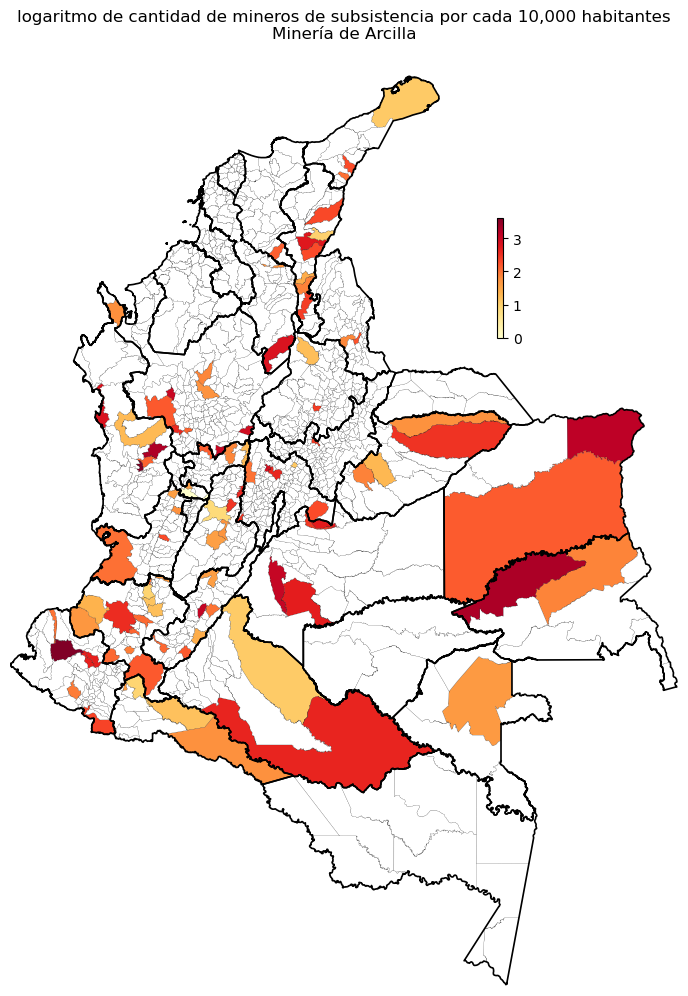

 12%|██████████▌                                                                         | 1/8 [00:09<01:08,  9.79s/it]

<Figure size 640x480 with 0 Axes>

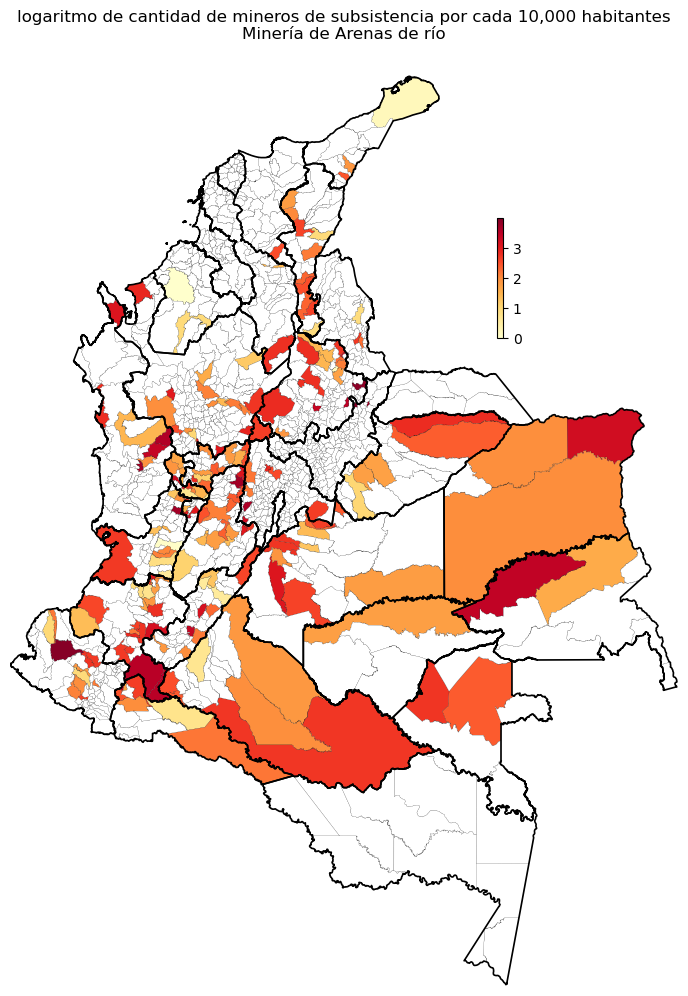

 25%|█████████████████████                                                               | 2/8 [00:19<00:58,  9.73s/it]

<Figure size 640x480 with 0 Axes>

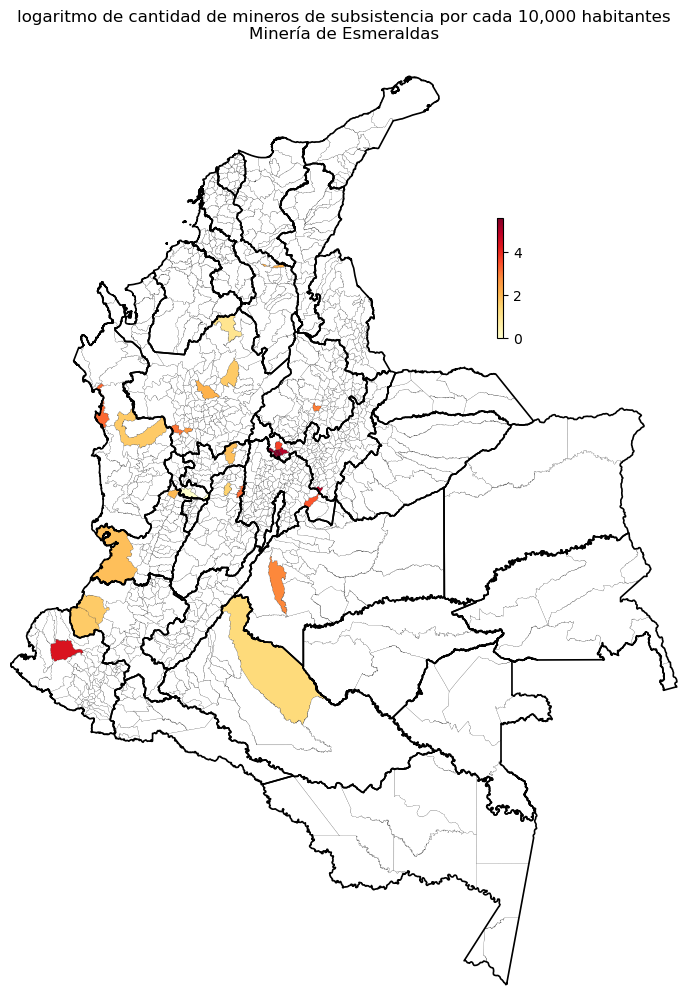

 38%|███████████████████████████████▌                                                    | 3/8 [00:29<00:48,  9.72s/it]

<Figure size 640x480 with 0 Axes>

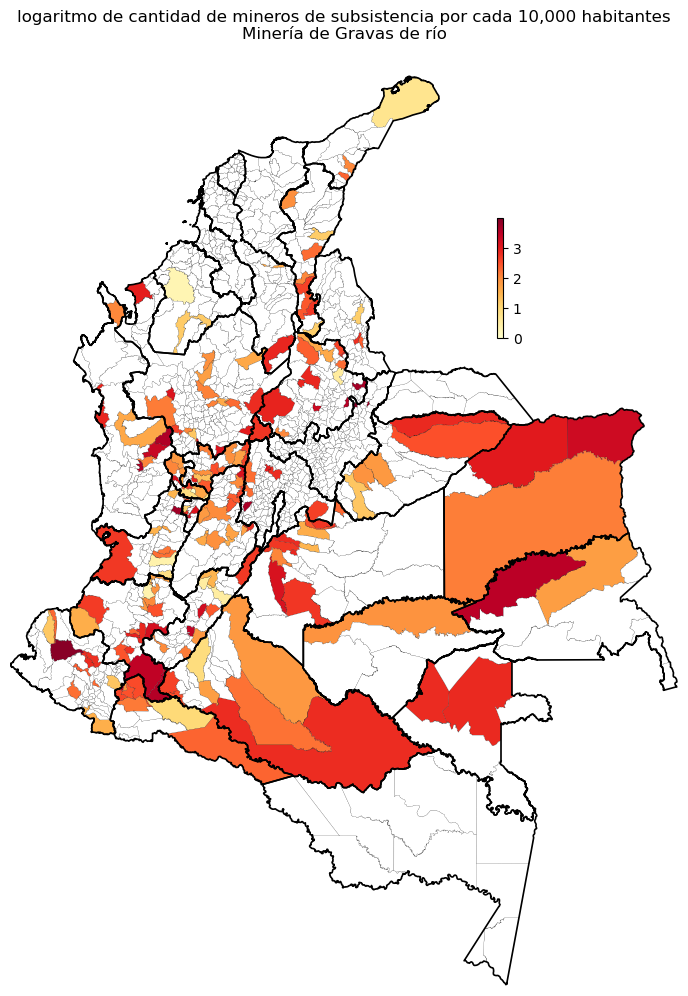

 50%|██████████████████████████████████████████                                          | 4/8 [00:39<00:39,  9.87s/it]

<Figure size 640x480 with 0 Axes>

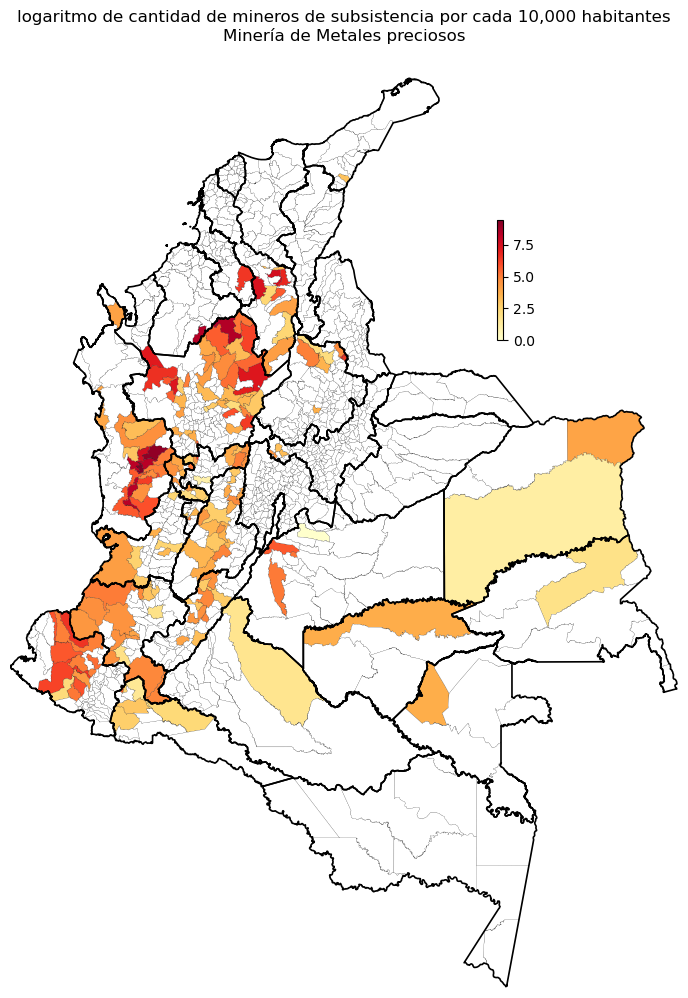

 62%|████████████████████████████████████████████████████▌                               | 5/8 [00:49<00:29,  9.92s/it]

<Figure size 640x480 with 0 Axes>

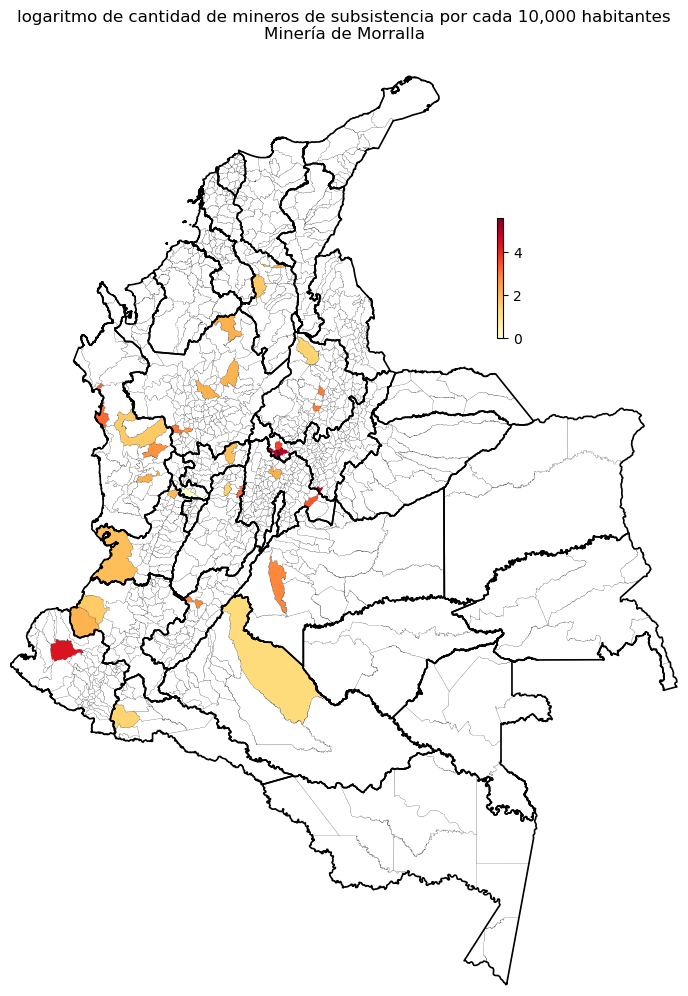

 75%|███████████████████████████████████████████████████████████████                     | 6/8 [00:58<00:19,  9.73s/it]

<Figure size 640x480 with 0 Axes>

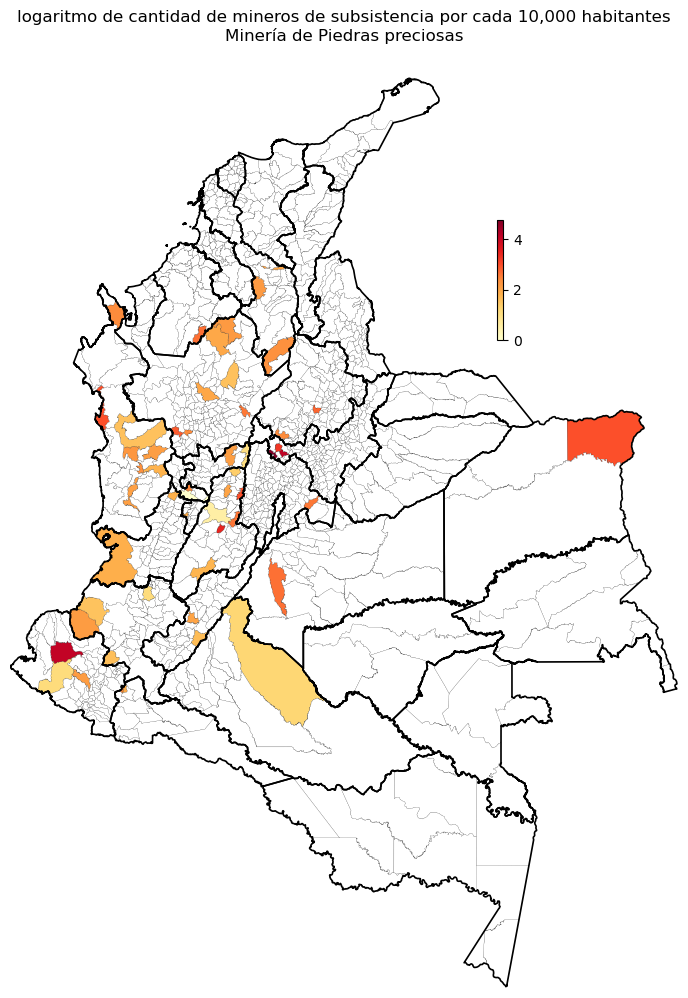

 88%|█████████████████████████████████████████████████████████████████████████▌          | 7/8 [01:10<00:10, 10.29s/it]

<Figure size 640x480 with 0 Axes>

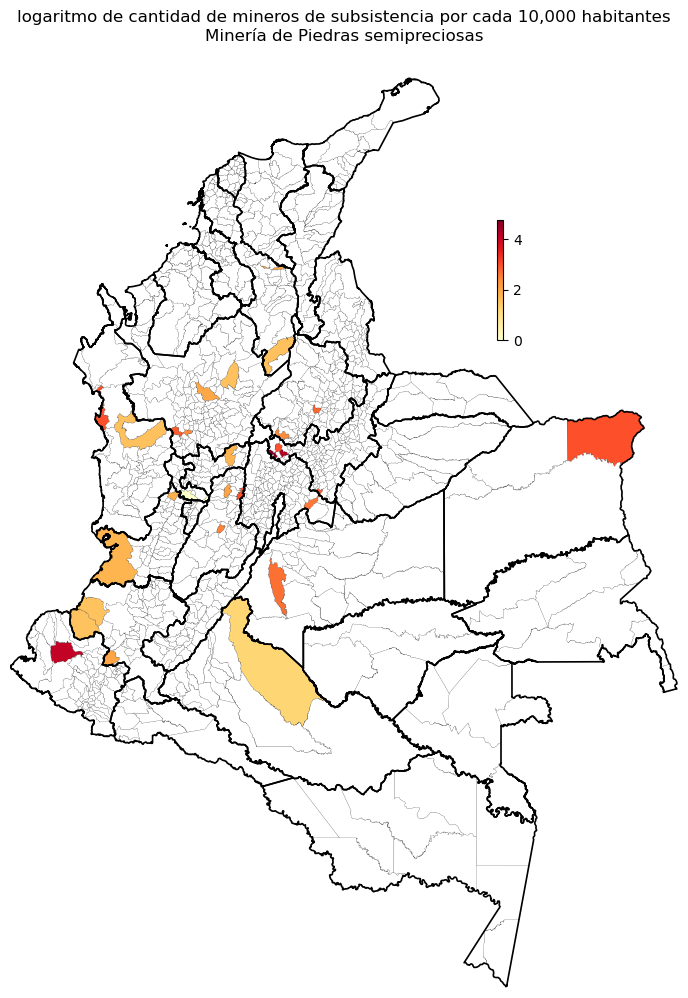

100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [01:19<00:00,  9.99s/it]


<Figure size 640x480 with 0 Axes>

In [99]:
numero_mapas = 1 # Contador de mapas

# Hacer el mapa de cada mineral
for mineral in tqdm(cols_mineros_x10khab):
    
    # Crear variable temporal con datos para graficar
    gdf_datos_municipales["temporal_graficar"] = np.log(gdf_datos_municipales[mineral].replace(0, np.nan))
    
    # Elementos básicos de la gráfica
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Contornos de departamentos ----------------------------------------------
    gdf_departamentos.boundary.plot(ax=ax, linewidth=1.2, color='black')

    # Colorear los municipios según la incidencia de minería de subsistencia -------------
    gdf_datos_municipales.plot(
        column="temporal_graficar",
        cmap="YlOrRd",
        ax=ax,
        legend=False,
        linewidth=0.1,
        edgecolor="black",
        missing_kwds={ # Pintar Nans como blanco
            "color": "white",
            "label": "0"
        }
    )

    # Crear barra de color horizontal ------------------------------------------
    # Variables auxiliares para manejar la leyenda de los colores
    # Definir normalización de colores
    vmin = 0
    vmax = gdf_datos_municipales["temporal_graficar"].max()
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.YlOrRd

    # Ubicar la barra de colores
    cax = fig.add_axes([0.6, 0.65, 0.08, 0.1])
    cax.set_axis_off()

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm._A = []  # necesario para matplotlib

    cbar = fig.colorbar(
        sm,
        ax=cax,
        orientation="vertical",
        fraction=0.5
    )
    
    # cbar.set_ticks([0, 25, 50, 75, 100]) # Ticks de la barra de colores

    # Incluir anotación como leyenda de la barra de colores
    # ax.annotate(text="Porcentaje del\nárea municipal",
    #             xy=(0.74,0.85), xycoords='axes fraction',
    #             ha='center', va='bottom')
    
    # Ejes -----------------------------------------------------------------------
    ax.set_xlim([0.45e6, 1.81e6])
    ax.set_ylim([0.02e6, 1.9e6])
    ax.set_axis_off()

    # Presentación de la gráfica --------------------------------------------------
    ax.set_title(f"{titulo_comun}\nMinería de {titulos_mapas[mineral]}")

    # Mostrar y exportar gráfica
    plt.show()
    plt.tight_layout()
    fig.savefig(f'./outputs/M{numero_mapas}_{mineral}.png', dpi=100)
    numero_mapas = numero_mapas + 1

In [96]:
mostrar_columnas = ['dpto_cnmbr', 'mpio_cnmbr', 'Poblacion', 'subsistencia_METALES_PRECIOSOS', 'subsistencia_METALES_PRECIOSOS_x10khab']
gdf_datos_municipales.sort_values(by='subsistencia_METALES_PRECIOSOS_x10khab', ascending=False)[mostrar_columnas]

,dpto_cnmbr,mpio_cnmbr,Poblacion,subsistencia_METALES_PRECIOSOS,subsistencia_METALES_PRECIOSOS_x10khab
604,CHOCÓ,UNIÓN PANAMERICANA,"7,322.00","9,399.00","12,836.66"
590,CHOCÓ,LLORÓ,"10,485.00","8,074.00","7,700.52"
34,ANTIOQUIA,CAUCASIA,"93,976.00","29,200.00","3,107.18"
453,CÓRDOBA,SAN JOSÉ DE URÉ,"15,711.00","4,717.00","3,002.36"
593,CHOCÓ,MEDIO SAN JUAN,"11,296.00","2,952.00","2,613.31"
...,...,...,...,...,...
423,CESAR,LA PAZ,"33,768.00",0.00,0.00
424,CESAR,SAN ALBERTO,"32,327.00",0.00,0.00
425,CESAR,SAN DIEGO,"24,353.00",0.00,0.00
426,CESAR,SAN MARTÍN,"34,997.00",0.00,0.00


# Exportar Datos

In [105]:
# Exportar datos en xlsx y parquet

# Exportar conteo de mineros de subsistencia por municipio, mineros de subsistencia x 10,000 habitantes y logaritmo de esta variable
# Tomé el logaritmo para los mapas porque hay municipios como Caucasia (Antioquia) o Unión Panamericana (Chocó) donde
# hay mayor número de mineros de subsistencia registrados que habitantes. 
# *** Tenerlo presente porque son datos para explorar

exportar = mineria_subsistencia_municipal.drop(['CODIGO_DANE'], axis=1).copy()
for mineral in cols_mineros_x10khab:
    # Agregar variables de logaritmos para que cuando remote los datos no se me olvide tratar el problema de que hay 
    # más mineros que personas en el municipio
    exportar[f"LOG_{mineral}"] = np.log(exportar[mineral].replace(0,np.nan))

exportar.to_parquet('./outputs/D1_mineros_subsistencia_x10000habitantes_NivObs_Municipio.parquet')
exportar.to_excel('./outputs/D1_mineros_subsistencia_x10000habitantes_NivObs_Municipio.xlsx')


# También voy a exportar los datos a nivel de miner
mineros_subsistencia.to_parquet('./outputs/D2_mineros_subsistencia_NivObs_Personas.parquet')
mineros_subsistencia.to_excel('./outputs/D2_mineros_subsistencia_NivObs_Personas.xlsx')